# Scenario Calendar

## Model Notes

**Principle:** Construct plausible Y2–Y5 calendars by perturbing the Y1 calendar, then re-run the peak simulation on each constructed calendar so the peak emerges from structure.

**Inputs**
- Y1 event list: for each event — on-hire start, on-hire end, win rate, and asset quantity by type (the footprint that creates overlaps).
- Event growth rate (e.g. 10%/yr) → applied to *event count*.
- Seasonal placement distribution: the empirical month-weights from Y1 (heavily Oct–Jan), expressed as a probability of a new event landing in each month.
- Number of placement draws per year (e.g. 200–500 constructed calendars).

**Step-by-step**
1. **Carry forward the base.** Y2 base calendar = the Y1 events (same dates, durations, quantities). This is the recurring spine.
2. **Compute new-event count.** New events in Y2 = round(Y1 count × growth) − Y1 count. (Y1=12 → Y2≈13 → 1 new event; Y3≈15 → 2 new; etc.) Round to whole events — you can't add 1.2 events.
3. **Characterise the "typical" new event.** Give each new event a duration and asset footprint drawn from the Y1 distribution (e.g. sample an existing event's profile, or use the median / typical-duration archetype). Don't invent an outlier unless you have a reason.
4. **Place each new event stochastically.** For each new event, draw a start month from the seasonal distribution (so most land Oct–Jan), then a start day within that month. This is the one random element.
5. **Assemble one constructed calendar** = base spine + placed new events.
6. **Re-run the peak simulation on it.** On that constructed calendar, run the win-rate Monte Carlo exactly as in Y1: coin-flip each event, walk the calendar day-by-day, record the peak. Repeat across trials → a peak distribution *for that one placement*.
7. **Repeat placement draws.** Do steps 4–6 across many placements. Each placement yields its own peak distribution; pool them. The pooled distribution now reflects *both* win uncertainty *and* schedule-placement uncertainty.
8. **Read the percentile.** Take the P85 (or chosen coverage percentile) of the *pooled* distribution → required fleet for Y2.
9. **Roll forward.** Y3 base = Y2 base + Y2's new events (now part of the recurring spine); repeat steps 2–8 for Y3, Y4, Y5.

**Outputs (per year)**
- A peak demand distribution (not a point) by asset type.
- Required owned fleet at the chosen percentile.
- Capex = max(0, required fleet − fleet held), stepped only when the re-derived peak breaches the owned line.

**Key property:** the peak now moves in steps — a new event either collides with the Oct–Jan cluster (peak jumps) or lands in a trough (peak flat) — because it's read off a calendar, not scaled. The roll-forward propagates the spine so each year inherits the prior year's structure.

```txt
Y1 list ──► [carry forward spine] ──► add round(count×growth) new events
                                          │
                          draw month (seasonal wts) + day  ── one placement
                                          │
                              assemble constructed calendar
                                          │
                          win-rate Monte Carlo on that calendar ─► peak dist (this placement)
                                          │
              repeat over many placements ─► POOLED peak dist
                                          │
                              read P85 ─► required fleet ─► capex (stepped)
                                          │
              spine += this year's new events ─► next year
```

**Model flaws**

1) **Placement uncertainty collapses at the year boundary**: Within a year (step 4) new events are placed stochastically (re-drawn each placement). But at the end of the year, the roll-forward commits the new events to the spine via a single draw — one random placement — which then becomes fixed history for all future years. The cost is that later-year peaks are conditioned on one arbitrary placement history rather than the distribution of histories. The current structure understates compounding uncertainty, but is a pragmatic way to avoid combinatorial explosion of structuring an events tree ($\text{Calendar Placements}^7$ by year 8).
2) **Re-signing is treated as independent: event acquisition vs renewals**: Every year, the model re-flips every event in the spine at its static win rate. So the model assumes your probability of resigning an event in Y2 has the same probability of winning as winning it cold, even though in reality a recurring event you delivered last year should re-sign at a much higher rate (incumbency, relationship, proven delivery). The model treats every year as a fresh tender for the entire portfolio. That systematically understates the recurring base and therefore understates the stable, ownable peak — it makes demand look more volatile and less recurring than it really is. For a business whose whole thesis is "these events repeat and we grow the relationship," that's a meaningful conservatism in the wrong direction.
3) **Win probabilities stay static through market maturation**: As reputation and the market grow, cold acquisition rates might drift up. This is a gentle annual escalator on the base win rate. However, it has mild effects, can be easily overstated, and this rate is bound to plateau due to competition.
4) **Events can be correlated and lack independence**: The simulation flips each event independently, but real wins can be correlated — the same organizers and venues drive several events, so a good relationship year lifts several at once. This fattens the tails, and our P85 coverage is somewhat higher than the independent simulation reports. Modeling it properly means introducing a shared latent factor (a "good year / bad year" draw per organizer that nudges all their events' win draws together) rather than independent coin-flips. However this is the hardest to parametrize and model and can be avoided.

**Caution**
Each added dependency makes the model less transparent and adds parameters you can't observe well (what is the renewal rate for Saadiyat Nights? It's anyone's guess). The current independent model is wrong in known, conservative directions — it understates the recurring base (a) and understates the tail (c). Knowing the direction of the error is itself useful. Before adding machinery, decide whether a defensible conservative bias is actually a problem for the decision you're making, or whether it's a feature you can state plainly: "this sizing assumes we re-win nothing automatically and events are independent — both push the number down, so it's a floor, not a forecast." 

### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

## Inputs

In [2]:
ASSETS = ["cabins", "buggies", "barriers", "fencing", "flooring"]
COVERAGE_PCT = np.array([0.85, 0.5, 0.85, 0.85, 0.85]) # Percentile to own

# Analysis window
YEAR = 8

# Event growth rate
GROWTH = 0.10

# Simulation scale
CALENDAR_PLACEMENTS = 300 # more schedule scenarios
PEAK_TRIALS = 4_000 # tighter win-rate distribution

# Months in season order (Oct..Sep) and their lengths, used to place new events.
MONTHS = [10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8, 9]
MONTH_LEN = [31, 30, 31, 31, 28, 31, 30, 31, 30, 31, 31, 30]
MONTH_START = np.cumsum([0] + MONTH_LEN[:-1])  # day offset of each month's 1st

SEED=8
RNG = np.random.default_rng(SEED)

### Y1 Event Calendar

In [3]:
# (name, win rate, hire start, hire end, cabin, buggies, barriers, fencing, flooring)
events = [
    ('Saadiyat Nights',0.5,1,157,10,10,0,0,280),
    ('BRED X',0.5,22,43,8,0,0,0,0),
    ('MOTN DHA',0.5,34,56,8,6,350,550,0),
    ('No Art',0.5,36,57,24,6,0,0,200),
    ('Tanweer Festival',0.5,44,56,0,8,900,50,200),
    ('MOTN AAN',0.5,40,66,18,6,350,550,0),
    ('Keinemusik',0.5,57,69,29,8,714,1180,178),
    ('MOTN AUH',0.5,50,102,20,10,700,1100,200),
    ('Yas Winterfest',0.5,56,88,6,4,644,760,60),
    ('Animenia',0.5,118,140,8,4,288,192,0),
    ('DAZ',0.5,170,200,15,4,775,225,60),
    ('BRED',0.5,196,210,22,6,1500,500,0),
]
event_names = [e[0] for e in events]
win_rate = np.array([r[1] for r in events])
start = np.array([r[2] for r in events])
end = np.array([r[3] for r in events])
qty = np.array([r[4:] for r in events], dtype=float)

### Seasonal Weights

In [4]:
days = np.arange(365)
on_hire = (days[None, :] >= start[:, None]) & (days[None, :] <= end[:, None])
on_hire = on_hire.astype(np.float32)

# presence/occupancy weight (not an event-start weight)
# Event count per month (regardless of duration. provides a coarse seasonal shape)
counts = np.array([np.count_nonzero(on_hire[:,s:s+l].sum(axis=1)) for s, l in zip(MONTH_START, MONTH_LEN)])
y1_weights = counts / counts.sum()

for month, count, weight in zip(MONTHS, counts, y1_weights):
    print(f"{month:>2}: {count:2d} events ({weight:6.1%})")

10:  2 events (  8.0%)
11:  9 events ( 36.0%)
12:  5 events ( 20.0%)
 1:  3 events ( 12.0%)
 2:  2 events (  8.0%)
 3:  2 events (  8.0%)
 4:  2 events (  8.0%)
 5:  0 events (  0.0%)
 6:  0 events (  0.0%)
 7:  0 events (  0.0%)
 8:  0 events (  0.0%)
 9:  0 events (  0.0%)


In [5]:
# Day-weighted occupancy per month
counts = np.array([on_hire[:,s:s+l].sum(axis=0).sum() for s, l in zip(MONTH_START, MONTH_LEN)], dtype=int)
y1_weights = counts / counts.sum()

for month, count, weight in zip(MONTHS, counts, y1_weights):
    print(f"{month:>2}: {count:2d} events ({weight:6.1%})")

10: 39 events (  9.0%)
11: 142 events ( 32.9%)
12: 105 events ( 24.3%)
 1: 47 events ( 10.9%)
 2: 46 events ( 10.6%)
 3: 19 events (  4.4%)
 4: 34 events (  7.9%)
 5:  0 events (  0.0%)
 6:  0 events (  0.0%)
 7:  0 events (  0.0%)
 8:  0 events (  0.0%)
 9:  0 events (  0.0%)


In [6]:
# Seasonal weights for placing NEW events (Oct..Sep) — concentrated Oct–Jan.
weights = np.array([4, 14, 8, 6, 4, 2, 1, 0, 0, 0, 0, 0])
MONTH_WEIGHTS = weights / weights.sum()

for month, weight in zip(MONTHS, MONTH_WEIGHTS):
    print(f"{month:>2}: {weight:6.1%}")

10:  10.3%
11:  35.9%
12:  20.5%
 1:  15.4%
 2:  10.3%
 3:   5.1%
 4:   2.6%
 5:   0.0%
 6:   0.0%
 7:   0.0%
 8:   0.0%
 9:   0.0%


### Event Duration Archetype

In [7]:
dur = end - start + 1
mean_dur = np.mean(dur, axis=0)
median_dur = np.median(dur, axis=0)

In [8]:
print(f"""Mean Dur.: {mean_dur:.0f}days
Median Dur.: {median_dur:.0f}days

Min. Dur.: {np.min(dur)}days
Max. Dur.: {np.max(dur)}days
""")

Mean Dur.: 36days
Median Dur.: 23days

Min. Dur.: 13days
Max. Dur.: 157days



### Asset Requirement Archetype

In [9]:
mean_qty = np.mean(qty, axis=0)
median_qty = np.median(qty, axis=0)

width = max(len(asset) for asset in ASSETS)
print(f"{'Asset':<{width}}  {'Mean':>10}  {'Median':>10}")
print(f"{'-' * width}  {'-' * 10}  {'-' * 10}")
for asset, mean, median in zip(ASSETS, mean_qty, median_qty):
    print(
        f"{asset:<{width}}  "
        f"{mean:10.1f}  "
        f"{median:10.1f}"
    )

Asset           Mean      Median
--------  ----------  ----------
cabins          14.0        12.5
buggies          6.0         6.0
barriers       518.4       497.0
fencing        425.6       362.5
flooring        98.2        60.0


### Event Archetype

In [10]:
# (duration, win rate, ["cabins", "buggies", "barriers", "fencing", "flooring"])
ARCHETYPE = (25, 0.5, np.array([13, 6, 500, 400, 100], dtype=float))

### Horizon

In [11]:
# Calendar window in days for peak demand simulation 
# Extend to cover every event's full on-hire span

last_season_month = np.nonzero(weights)[0][-1] + 1
# Last day of the last active month + duration of archetype event
max_horizon = MONTH_START[last_season_month] - 1 + ARCHETYPE[0]
max_horizon

np.int64(236)

In [12]:
# Select max horizon of 1 year or clipped off empty trailing columns that can never contain the peak
HORIZON = max(max_horizon, end.max()+1) # or 365

## Simulation

### Peak Simulation

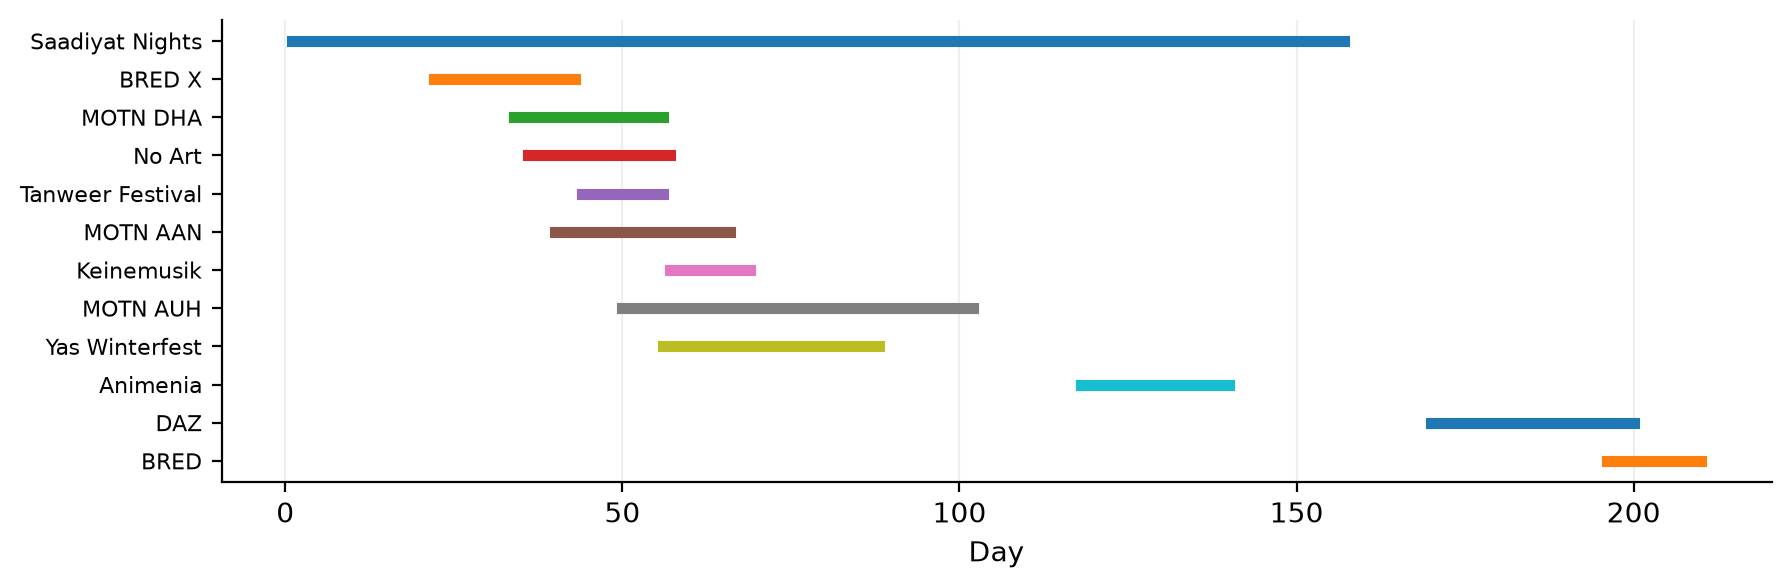

In [13]:
# on_hire[i, d]  = 1 if event i is on hire on day d
days = np.arange(HORIZON)
on_hire = (days[None, :] >= start[:, None]) & (days[None, :] <= end[:, None])
on_hire = on_hire.astype(np.float32)

offsets = np.arange(len(events), 0, -1)

fig, ax = plt.subplots(figsize=(10, 3))

for i in range(len(events)):
    ax.plot(
        days,
        np.where(on_hire[i], offsets[i], np.nan),
        lw=4,
    )

ax.set_xlabel("Day")
ax.set_yticks(offsets)
ax.set_yticklabels(event_names, fontsize=8)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.2)

plt.show()

In [14]:
signed = (RNG.random((PEAK_TRIALS, len(start))) < win_rate).astype(np.float32)

results = np.unique(signed.sum(axis=1), return_counts=True)

width = max(results[1]) // 100
print("Count of total signed events across trials:")
print()
print(f"{'# Events':<10}  {'Trails':<{width}}")
print(f"{'-' * 10}  {'-' * width}")
for event, count in zip(*results):
    print(f"{event:<10.0f} {count:<{width}}")

Count of total signed events across trials:

# Events    Trails  
----------  --------
1          12      
2          80      
3          215     
4          498     
5          818     
6          851     
7          738     
8          496     
9          211     
10         67      
11         12      
12         2       


In [15]:
results = signed.sum(axis=0)

print("Count of signed events across trials:")
print()
print(f"{'Events':<20}  {'Trails':<10}")
print(f"{'-' * 20}  {'-' * 10}")
for event, count in zip(event_names, results):
    print(f"{event:<20} {count:<10.0f}")

Count of signed events across trials:

Events                Trails    
--------------------  ----------
Saadiyat Nights      2006      
BRED X               1954      
MOTN DHA             2002      
No Art               2054      
Tanweer Festival     1971      
MOTN AAN             2003      
Keinemusik           1958      
MOTN AUH             1986      
Yas Winterfest       1952      
Animenia             1974      
DAZ                  1987      
BRED                 2017      


In [16]:
peaks = np.empty((PEAK_TRIALS, len(ASSETS)), dtype=np.float32)
for a in range(len(ASSETS)):
    units_per_day = on_hire * qty[:, a][:, None]  # (n_events x HORIZON)
    demand = signed @ units_per_day  # (PEAK_TRIALS x HORIZON)
    peaks[:, a] = demand.max(axis=1)
peaks

array([[  83.,   38., 2408., 3590.,  718.],
       [  42.,   24., 2275.,  725.,  680.],
       [  86.,   42., 2275., 2960.,  740.],
       ...,
       [  37.,   28., 2275., 1360.,  540.],
       [  89.,   38., 2275., 3040.,  940.],
       [  67.,   24., 1764., 2830.,  378.]],
      shape=(4000, 5), dtype=float32)

In [17]:
def simulate_peaks(start, end, qty, win_rate):
    """Coin-flip each event PEAK_TRIALS times; for the events that 'sign', walk the
    calendar and record the highest concurrent demand. Returns the peak for
    every trial: an array of shape (PEAK_TRIALS, n_assets).

      - on_hire[i, d]  = 1 if event i is on hire on day d
      - signed[t, i]   = 1 if event i won in trial t  (the coin flip)
      - demand[t, d]   = sum over signed events of their qty on that day
      - peak[t]        = max over days
    """
    n_events = len(start)

    # on_hire[i, d] : is event i on hire on day d?   (n_events x HORIZON)
    days = np.arange(HORIZON)
    on_hire = (days[None, :] >= start[:, None]) & (days[None, :] <= end[:, None])
    on_hire = on_hire.astype(np.float32)

    # signed[t, i] : did event i sign in trial t?   (PEAK_TRIALS x n_events)
    signed = (RNG.random((PEAK_TRIALS, n_events)) < win_rate).astype(np.float32)

    # Per asset: daily demand = signed events' units summed by day; peak = max day.
    peaks = np.empty((PEAK_TRIALS, len(ASSETS)), dtype=np.float32)
    for a in range(len(ASSETS)):
        units_per_day = on_hire * qty[:, a][:, None]  # (n_events x HORIZON)
        demand = signed @ units_per_day  # (PEAK_TRIALS x HORIZON)
        peaks[:, a] = demand.max(axis=1)
    return peaks

In [18]:
peaks = simulate_peaks(start, end, qty, win_rate)
peaks

array([[  63.,   24.,  900., 1180.,  680.],
       [  29.,    8.,  714., 1180.,  178.],
       [  86.,   42., 2275., 2960.,  740.],
       ...,
       [  60.,   26., 2275., 1310.,  540.],
       [  40.,   28., 1544.,  810.,  740.],
       [  79.,   34., 2594., 3040.,  660.]],
      shape=(4000, 5), dtype=float32)

### Add New Events

In [19]:
count = len(start)
n_new = round(count * (1 + GROWTH)) - round(count) # year 2

array([0.1025641 , 0.35897436, 0.20512821, 0.15384615, 0.1025641 ,
       0.05128205, 0.02564103, 0.        , 0.        , 0.        ,
       0.        , 0.        ])

In [20]:
def add_new_events(start, end, qty, win_rate, n_new, deterministic=False):
    """Return a new calendar = spine + n_new ARCHETYPE events, each placed in a
    month drawn from MONTH_WEIGHTS on a random day.
    
    deterministic=True places every new event in the single highest-weight
    month (used to commit the modal calendar when rolling the spine forward).
    """
    if n_new == 0:
        return start, end, qty, win_rate

    arch_dur, arch_win_rate, arch_qty = ARCHETYPE
    new_start, new_end, new_win_rate, new_qty = [], [], [], []
    for _ in range(n_new):
        if deterministic:
            # commit new events deterministically at their highest-weight months
            m = int(MONTH_WEIGHTS.argmax())
            day_offset = 0
        else:
            m = RNG.choice(len(MONTHS), p=MONTH_WEIGHTS)  # pick a month
            day_offset = RNG.integers(0, MONTH_LEN[m])    # pick a day in selected month
        day = MONTH_START[m] + day_offset  
        new_start.append(day)
        new_end.append(day + arch_dur - 1)
        new_qty.append(arch_qty)
        new_win_rate.append(arch_win_rate)

    start = np.concatenate([start, new_start])
    end = np.concatenate([end, new_end])
    qty = np.vstack([qty, new_qty])
    win_rate = np.concatenate([win_rate, new_win_rate])
    return start, end, qty, win_rate

In [21]:
s, e, q, w = add_new_events(start, end, qty, win_rate, n_new)

In [22]:
add_new_events(start, end, qty, win_rate, 3)

(array([  1,  22,  34,  36,  44,  40,  57,  50,  56, 118, 170, 196, 130,
        198, 115]),
 array([157,  43,  56,  57,  56,  66,  69, 102,  88, 140, 200, 210, 154,
        222, 139]),
 array([[  10.,   10.,    0.,    0.,  280.],
        [   8.,    0.,    0.,    0.,    0.],
        [   8.,    6.,  350.,  550.,    0.],
        [  24.,    6.,    0.,    0.,  200.],
        [   0.,    8.,  900.,   50.,  200.],
        [  18.,    6.,  350.,  550.,    0.],
        [  29.,    8.,  714., 1180.,  178.],
        [  20.,   10.,  700., 1100.,  200.],
        [   6.,    4.,  644.,  760.,   60.],
        [   8.,    4.,  288.,  192.,    0.],
        [  15.,    4.,  775.,  225.,   60.],
        [  22.,    6., 1500.,  500.,    0.],
        [  13.,    6.,  500.,  400.,  100.],
        [  13.,    6.,  500.,  400.,  100.],
        [  13.,    6.,  500.,  400.,  100.]]),
 array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
        0.5, 0.5]))

In [23]:
simulate_peaks(s, e, q, w)

array([[  71.,   26., 1600., 1730.,  400.],
       [  53.,   18., 1894., 2490.,  260.],
       [  83.,   38., 2594., 3590.,  740.],
       ...,
       [  83.,   34., 1500., 2280.,  858.],
       [  73.,   28., 2408., 3590.,  438.],
       [  89.,   44., 2594., 3040.,  940.]],
      shape=(4000, 5), dtype=float32)

### Simulate Year

In [24]:
def simulate_year(start, end, qty, win_rate, n_new):
    """Build CALENDAR_PLACEMENTS (each with new events placed differently),
    run the win-rate sim on each, and pool all the peaks together."""
    pooled = []
    for _ in range(CALENDAR_PLACEMENTS):
        s, e, q, w = add_new_events(start, end, qty, win_rate, n_new)
        pooled.append(simulate_peaks(s, e, q, w))
    return np.concatenate(pooled)  # ((CALENDAR_PLACEMENTS*PEAK_TRIALS) x assets)

In [25]:
peaks = simulate_year(start, end, qty, win_rate, n_new)
peaks

array([[  69.,   28., 1358., 1940.,  718.],
       [ 107.,   44., 2408., 3590.,  918.],
       [  59.,   18., 1358., 1940.,  438.],
       ...,
       [  42.,   22.,  350.,  550.,  480.],
       [ 107.,   44., 2594., 3590.,  940.],
       [  69.,   28., 1358., 1940.,  718.]],
      shape=(1200000, 5), dtype=float32)

### Complete Timeline Simulation

In [26]:
def run(start, end, qty, win_rate, deterministic=True):
    """Roll the calendar forward, sizing fleet to the chosen percentile each year.
    
    Prints a small table per year and returns the per-year results.
    """

    count = len(start)
    fleet_held = np.zeros(len(ASSETS))
    results = []

    for yr in range(1, YEAR + 1):
        # step 2: how many whole new events this year (Y1 has none — it's real)
        n_new = 0 if yr == 1 else round(count * (1 + GROWTH)) - round(count)

        # steps 4–7: pooled peak distribution
        peaks = simulate_year(start, end, qty, win_rate, n_new)

        # step 8: read the percentile -> required fleet -> stepped capex
        required = np.ceil(np.quantile(peaks, COVERAGE_PCT, axis=0)).diagonal()
        capex = np.maximum(0, required - fleet_held)
        fleet_held = np.maximum(fleet_held, required)

        results.append({"year": yr, "new_events": n_new, "peaks": peaks, "required": required, "capex": capex})

        # step 9: commit this year's new events to the spine (place them once)
        if n_new:
            start, end, qty, win_rate = add_new_events(start, end, qty, win_rate, n_new, deterministic)
        count = round(count * (1 + GROWTH))

    _print(results)
    return results


def _print(results):
    pct = lambda p, peaks: np.percentile(peaks, p, axis=0)
    for r in results:
        print(f"\n=== YEAR {r['year']}  (+{r['new_events']} new events) ===")
        print("        " + "".join(f"{a:>10}" for a in ASSETS))
        for p in (50, 85, 95):
            print(f"  P{p:<4} " + "".join(f"{x:>10.0f}" for x in pct(p, r["peaks"])))
        print("  fleet " + "".join(f"{x:>10.0f}" for x in r["required"]))
        print("  buy   " + "".join(f"{x:>10.0f}" for x in r["capex"]))


In [27]:
results = run(start, end, qty, win_rate)


=== YEAR 1  (+0 new events) ===
            cabins   buggies  barriers   fencing  flooring
  P50           56        26      1894      1940       480
  P85           80        36      2300      2960       740
  P95           91        42      2594      3590       880
  fleet         80        26      2300      2960       740
  buy           80        26      2300      2960       740

=== YEAR 2  (+1 new events) ===
            cabins   buggies  barriers   fencing  flooring
  P50           59        28      1950      1940       540
  P85           83        38      2408      3010       740
  P95           97        44      2800      3590       918
  fleet         83        28      2408      3010       740
  buy            3         2       108        50         0

=== YEAR 3  (+1 new events) ===
            cabins   buggies  barriers   fencing  flooring
  P50           61        28      2100      2050       578
  P85           83        40      2558      3010       780
  P95           